In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
from tweezepy import allanvar as tpy
import statistics
import allanself

In [2]:
df = allanself.process_data('ICRF3 Dem/series_ind_dem/1611+343_dem.txt')
df.head(5)

,MJD,R.A. (mas),Dec. (mas),Err. R.A. (mas),Err. Dec. (mas),Corr.,Del.,R.A. (micas),Dec. (micas),Err. R.A. (micas),Err. Dec. (micas),Dec. (rad),RAcosDEC,BY
0,47165.332,1.472509,4.937699,0.5046,1.0159,-0.003,21,1472.508509,4937.698813,504.6,1015.9,2.393864e-08,1472.508509,1988.010690
1,47610.794,47.422934,7.737098,3.1809,1.6415,0.835,3,47422.934133,7737.098412,3180.9,1641.5,3.751051e-08,47422.934133,1989.230324
2,47620.338,0.554842,-0.460800,1.0507,1.1907,-0.022,11,554.842071,-460.799987,1050.7,1190.7,-2.234021e-09,554.842071,1989.256455
3,47640.018,243.542066,-967.786099,6.7731,6.0100,-0.593,3,243542.065678,-967786.099196,6773.1,6010.0,-4.691959e-06,243542.065675,1989.310337
4,47655.329,2.151144,2.641702,0.7536,0.9041,0.061,20,2151.144024,2641.701590,753.6,904.1,1.280733e-08,2151.144024,1989.352257


In [4]:
len(df)

2050

In [5]:
# Choose data under 2015
df_sel = df[df['BY'] < 2015]
len(df_sel)

1922

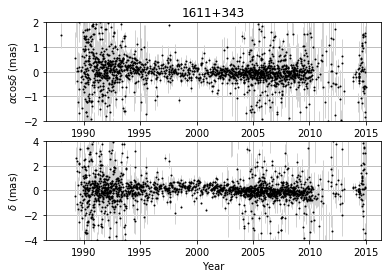

In [6]:
plt.subplot(211)
plt.title('1611+343')
plt.errorbar(df_sel['BY'], df_sel['RAcosDEC']/1000,yerr=df_sel['Err. R.A. (mas)'], fmt='o', ms=1, mec='black', ecolor='lightgrey', elinewidth=1)
plt.ylim(-2,2)
plt.xlabel('Year')
plt.ylabel(r'$\alpha \cos \delta$ (mas)')
plt.grid()
plt.subplot(212)
plt.errorbar(df_sel['BY'], df_sel['Dec. (mas)'], yerr=df_sel['Err. Dec. (mas)'], fmt='o', ms=1, mec='black', ecolor='lightgrey', elinewidth=1)
plt.ylim(-4,4)
plt.xlabel('Year')
plt.ylabel('$\delta$ (mas)')
plt.grid()
plt.show()

# Remove outliers

We also considered as outliers data points whose distance to the mean computed on a two-year window, which is centered on the epoch of the tested data point, was larger than six times the series standard deviation computed on the same window.

## Dec data OLD

In [29]:
df_sel_dec_try = df_sel[['MJD','Dec. (micas)','Err. Dec. (micas)']].copy()
df_sel_dec_try.head(5)

,MJD,Dec. (micas),Err. Dec. (micas)
0,47165.332,4937.698813,1015.9
1,47610.794,7737.098412,1641.5
2,47620.338,-460.799987,1190.7
3,47640.018,-967786.099196,6010.0
4,47655.329,2641.701590,904.1


In [30]:
len(df_sel_dec_try)

1922

In [31]:
for index, row in df_sel_dec_try.iterrows():
    data_values = df_sel_dec_try[(df_sel_dec_try['MJD'] >= (row['MJD'] - 365)) & (df_sel_dec_try['MJD'] <= (row['MJD'] + 365))]
    mean = data_values['Dec. (micas)'].mean()
    std = data_values['Dec. (micas)'].std()
    print(mean,std)
    if abs(row['Dec. (micas)'] - mean) > 6*std:
        print('Outlier detected!' + str(row['Dec. (micas)']))
        df_sel_dec_try.drop(index, inplace = True)
        

4937.698813023 nan
-13178.771846341266 114948.79559758658
-12543.673342520413 111832.428252741
-11231.114270060536 105665.60756912624
Outlier detected!-967786.0991956779
196.88888130529992 2827.7673206688773
141.61392135746996 2717.2648345538305
174.4335816225049 2723.6892332611974
129.9381544165882 2747.1761324255394
121.23956924529725 2646.5040364106417
129.4373130695391 2621.2451405254337
152.3092288765508 2604.9218775800564
156.25199165609914 2770.1965598262504
154.20562096838205 2748.0774690640583
161.3967889728897 2945.5776711451317
412.690557927125 4085.477322398423
364.6423654660227 4045.1388294204544
244.41114808453727 4145.867026918044
351.1174618556934 4436.270412639225
305.5224019515942 4452.384915290834
316.2856392334071 4424.284225873864
300.9202006010209 4418.035720436893
277.8325733394965 4379.010865503129
276.9814913848552 4306.569893682935
275.5397900955098 4292.417211967378
274.73644790957684 4269.453767766078
257.9671943530314 4233.836187305914
257.9671943530314 423

In [ ]:
len(df_sel_dec)

# RAcosDEC data OLD

In [ ]:
df_sel_ra = df_sel[['MJD','RAcosDEC','Err. R.A. (micas)']].copy()
df_sel_ra.head(5)

In [ ]:
len(df_sel_ra)

In [ ]:
for index, row in df_sel_ra.iterrows():
    data_values = df_sel_ra[(df_sel_ra['MJD'] >= (row['MJD'] - 365)) & (df_sel_ra['MJD'] <= (row['MJD'] + 365))]
    mean = data_values['RAcosDEC'].mean()
    std = data_values['RAcosDEC'].std()
    if abs(row['RAcosDEC'] - mean) > 6*std:
        df_sel_ra.drop(index, inplace = True)

In [ ]:
len(df_sel_ra)

In [ ]:
# Try to make the function
def remove_outliers(df,data):
    if data == 'RA':
        df_sel = df[['MJD','RAcosDEC','Err. R.A. (micas)']].copy()
        datas = 'RAcosDEC'
    elif data == 'DEC':
        df_sel = df[['MJD','Dec. (micas)','Err. Dec. (micas)']].copy()
        datas = 'Dec. (micas)'
    else:
        print('Please choose RA/DEC data')

    for index, row in df_sel.iterrows():
        data_values = df_sel[(df_sel['MJD'] >= (row['MJD'] - 365)) & (df_sel['MJD'] <= (row['MJD'] + 365))]
        mean = data_values[datas].mean()
        std = data_values[datas].std()
        if abs(row[datas] - mean) > 6*std:
            df_sel.drop(index, inplace = True)
            
    return df_sel

In [ ]:
df_sel_ra = remove_outliers(df_sel,'RA')
len(df_sel_ra)

# NEW with module func

In [7]:
df_sel_dec = allanself.remove_outliers(df_sel,'DEC')
len(df_sel_dec)

1906

In [8]:
df_sel_ra = allanself.remove_outliers(df_sel,'RA')
len(df_sel_ra)

1902

# Overlapping Allan Std Dev

In [9]:
%%time
tau_dec, allanstd_dec, edfs_dec = allanself.allanoadev(df_sel_dec['Dec. (micas)'].values,df_sel_dec['MJD'].values,df_sel_dec['Err. Dec. (micas)'].values)

CPU times: user 3min 12s, sys: 10.7 ms, total: 3min 12s
Wall time: 3min 12s


In [17]:
def process_allan(y,tau,edfs):
    tau_year = [x/365.242198781 for x in tau]
    samplevar = statistics.variance(y)
    bottom = edfs*samplevar/scipy.stats.chi2.ppf(1-0.1/2,edfs)
    top = scipy.stats.chi2.ppf(0.1/2,edfs)
    top_alt = edfs*samplevar/scipy.stats.chi2.ppf(0.1/2,edfs)
    return tau_year,bottom,top,top_alt

In [18]:
tau_dec_year, bottom_dec, top_dec, top_alt_dec = allanself.process_allan(df_sel_dec['Dec. (micas)'].values,tau_dec,edfs_dec)

In [19]:
statistics.variance(df_sel_dec['Dec. (micas)'])

15485784.971111517

In [24]:
df_sel_dec.to_csv('1611+343_2015_dec.csv')

In [27]:
min(df_sel_dec['Dec. (micas)'])

-56049.901206734

In [28]:
min(df_sel['Dec. (micas)'])

-1043354.199606483

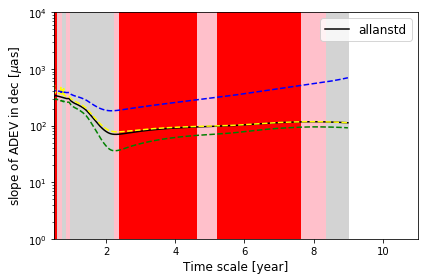

In [13]:
plt.figure()
# Calculate the slopes
slopes_dec = np.diff(np.log10(allanstd_dec)) / np.diff(np.log10(tau_dec))
# Plot allanstd
plt.plot(tau_dec_year,allanstd_dec,color='black',label='allanstd')
# Color background according to the slopes / noise type
plt.fill_between(tau_dec_year[1:], 1, 10**4, where= slopes_dec  < -0.25,color='lightgray',linewidth=1.0,zorder=1)
plt.fill_between(tau_dec_year[1:], 1, 10**4, where= (-0.25 <= slopes_dec ) & (slopes_dec  <= 0.25),color='pink',linewidth=1.0)
plt.fill_between(tau_dec_year[1:], 1, 10**4, where= slopes_dec  > 0.25,color='red',step='mid',linewidth=1.0)
# Plot confidence interval
plt.plot(tau_dec_year, allanstd_dec - bottom_dec,color='green',linestyle='dashed')
plt.plot(tau_dec_year, allanstd_dec + top_dec,color='yellow',linestyle='dashed')
plt.plot(tau_dec_year, allanstd_dec + top_alt_dec,color='blue',linestyle='dashed')

plt.yscale('log')
plt.xlabel('Time scale [year]', fontsize=12)
plt.ylabel(r'slope of ADEV in dec [$\mu$as]', fontsize=12)
plt.legend(fontsize=12)
plt.ylim(1,10**4)
plt.xlim(0.5,11)
plt.tight_layout()

In [16]:
%%time
tau_ra, allanstd_ra, edfs_ra = allanself.allanoadev(df_sel_ra['RAcosDEC'].values,df_sel_ra['MJD'].values,df_sel_ra['Err. R.A. (micas)'].values)

CPU times: user 3min 11s, sys: 24 ms, total: 3min 11s
Wall time: 3min 11s


In [15]:
tau_ra_year, bottom_ra, top_ra, top_alt_ra = process_allan(df_sel_ra['RAcosDEC'].values,tau_ra,edfs_ra)

NameError: name 'process_allan' is not defined

In [ ]:
plt.figure()
# Calculate the slopes
slopes_ra = np.diff(np.log10(allanstd_ra)) / np.diff(np.log10(tau_ra))
# Plot allanstd
plt.plot(tau_ra_year,allanstd_ra,color='black',label='allanstd')
# Color background according to the slopes / noise type
plt.fill_between(tau_ra_year[1:], 1, 10**4, where= slopes_ra  < -0.25,color='lightgray',linewidth=1.0,zorder=1)
plt.fill_between(tau_ra_year[1:], 1, 10**4, where= (-0.25 <= slopes_ra ) & (slopes_ra  <= 0.25),color='pink',linewidth=1.0)
plt.fill_between(tau_ra_year[1:], 1, 10**4, where= slopes_ra  > 0.25,color='red',step='mid',linewidth=1.0)
# Plot confidence interval
plt.plot(tau_ra_year, allanstd_ra - bottom_ra,color='GREEN',linestyle='dashed')
plt.plot(tau_ra_year, allanstd_ra + top_ra,color='yellow',linestyle='dashed')
plt.plot(tau_ra_year, allanstd_ra + top_alt_ra,color='blue',linestyle='dashed')

plt.yscale('log')
plt.xlabel('Time scale [year]', fontsize=12)
plt.ylabel(r'slope of ADEV in $\alpha\cos{\delta}$ [$\mu$as]', fontsize=12)
plt.legend(fontsize=12)
plt.ylim(1,10**4)
plt.xlim(0.5,11)
plt.tight_layout()